## 4H. The location of remote content

Plot locations of the remote content and also the rat location when remote content happens.

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import xarray as xr
from scipy import stats
from scipy import linalg
import os
import pickle
import matplotlib.pyplot as plt

In [3]:
from spyglass.shijiegu.changeOfMind_figures.figure4d import find_angle_animal
from spyglass.shijiegu.Analysis_SGU import ChangeofMind

[2025-12-17 14:59:17,118][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306
[14:59:29][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[14:59:29][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[14:59:29][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[14:59:29][WARNING] Spyglass: Deprecation: this class has b

In [4]:
from spyglass.shijiegu.changeOfMind import nodes
from spyglass.shijiegu.decodeHelpers import session2position_name
from spyglass.shijiegu.helpers import interpolate_to_new_time

In [5]:
from spyglass.shijiegu.gyroscope import load_tracking_result, load_tracking_data_position

In [6]:
from spyglass.shijiegu.decodeHelpers import session2position_name
from spyglass.common.common_position import IntervalPositionInfo
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.shijiegu.ripple_add_replay import select_subset_helper, select_subset_helper_pd

In [7]:
from spyglass.shijiegu.changeOfMind_remote_location import find_location_animal
from spyglass.shijiegu.Analysis_SGU import ChangeofMindRemoteTheta
from spyglass.shijiegu.changeOfMind_triggered import region, linear_map, wellregion

In [130]:
def return_save_name(animal, encoding_set, classifier_param_name, d1, d2, proportion = 0.1):
    save_name = f'{animal.lower()}_{encoding_set}_{classifier_param_name}_{d1}_{d2}_p{proportion}_remote_locations'
    return save_name

In [132]:
list_of_days_animals, encoding_set_animals, classifier_param_name_animals, success = {}, {}, {}, {}

In [234]:
animal = "molly"
list_of_days_animals[animal] = ['20220416','20220417','20220418','20220419','20220420']
encoding_set_animals[animal] = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'

animal = "klein"
list_of_days_animals[animal] = ['20231101','20231102','20231103','20231104','20231105',#
                 '20231106','20231107','20231108','20231109','20231111']
encoding_set_animals[animal] = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'

animal = "julio"
list_of_days_animals[animal] = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']
encoding_set_animals[animal] = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'

animal = 'lewis'
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109',
                 '20240110','20240113','20240114']
encoding_set_animals[animal]  = '2Dheadspeed_above_4'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'

animal = "eliot"
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']
encoding_set_animals[animal] = '2Dheadspeed_above_4_andlowmua'
classifier_param_name_animals[animal] = 'default_decoding_gpu_4armMaze'

In [284]:
for animal in ["molly","julio","eliot","lewis","klein"]:
    list_of_days = list_of_days_animals[animal]
    encoding_set = encoding_set_animals[animal]
    list_of_days_to_process = list_of_days
    classifier_param_name = classifier_param_name_animals[animal]
    proportion = 0.1
    
    replay_locations, animal_locations, replay_arm_identities, replay_arm_proportions = find_location_animal(animal, list_of_days, list_of_days_to_process, encoding_set,
                          classifier_param_name, proportion, use_1d = 1, debug = False)
    
    data = {"replay_locations": replay_locations, "animal_locations": animal_locations,
            "replay_arm_identities": replay_arm_identities,
           "replay_arm_proportions": replay_arm_proportions}
    
    output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4/'
    save_name = return_save_name(animal, encoding_set, classifier_param_name, list_of_days[0], list_of_days[-1], proportion = 0.1)
    file_path = output_folder + save_name + '.pkl' 
    with open(file_path, 'wb') as file:
        pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Data successfully pickled and saved to {file_path}")
    
    success[animal] = True

[16:55:12][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.


Loading from spyglass database instead of pickle file.
molly20220416_.nwb 02_Seq2Session1
molly20220416_.nwb 04_Seq2Session2
molly20220416_.nwb 06_Seq2Session3
molly20220416_.nwb 08_Seq2Session4
molly20220416_.nwb 10_Seq2Session5
molly20220417_.nwb 02_Seq2Session1
molly20220417_.nwb 04_Seq2Session2
molly20220417_.nwb 06_Seq2Session3
molly20220417_.nwb 08_Seq2Session4
molly20220417_.nwb 10_Seq2Session5
molly20220418_.nwb 02_Seq2Session1
molly20220418_.nwb 04_Seq2Session2
molly20220418_.nwb 06_Seq2Session3
molly20220418_.nwb 08_Seq2Session4
molly20220418_.nwb 10_Seq2Session5
molly20220419_.nwb 02_Seq2Session1
molly20220419_.nwb 04_Seq2Session2
molly20220419_.nwb 06_Seq2Session3
molly20220419_.nwb 08_Seq2Session4
molly20220419_.nwb 10_Seq2Session5
molly20220420_.nwb 02_Seq2Session1
molly20220420_.nwb 04_Seq2Session2
molly20220420_.nwb 06_Seq2Session3


[2025-12-18 16:55:13,194][WARNING]: Skipped checksum for file with hash: 9ee2e2bb-39c7-6fe1-1432-6b883d7173db, and path: /stelmo/nwb/analysis/molly20220417_13UDVY7460.nwb
[2025-12-18 16:55:13,206][WARNING]: Skipped checksum for file with hash: 9ee2e2bb-39c7-6fe1-1432-6b883d7173db, and path: /stelmo/nwb/analysis/molly20220417_13UDVY7460.nwb
[2025-12-18 16:55:13,217][WARNING]: Skipped checksum for file with hash: 9ee2e2bb-39c7-6fe1-1432-6b883d7173db, and path: /stelmo/nwb/analysis/molly20220417_13UDVY7460.nwb
[2025-12-18 16:55:13,222][WARNING]: Skipped checksum for file with hash: 9ee2e2bb-39c7-6fe1-1432-6b883d7173db, and path: /stelmo/nwb/analysis/molly20220417_13UDVY7460.nwb


molly20220420_.nwb 08_Seq2Session4
molly20220420_.nwb 10_Seq2Session5
molly20220420_.nwb 12_Seq2Session6


[2025-12-18 16:55:13,451][WARNING]: Skipped checksum for file with hash: bf964d76-183c-dce6-5bce-173e8517b39b, and path: /stelmo/nwb/analysis/molly20220417_F16B8I784K.nwb
[2025-12-18 16:55:13,461][WARNING]: Skipped checksum for file with hash: bf964d76-183c-dce6-5bce-173e8517b39b, and path: /stelmo/nwb/analysis/molly20220417_F16B8I784K.nwb
[2025-12-18 16:55:13,472][WARNING]: Skipped checksum for file with hash: bf964d76-183c-dce6-5bce-173e8517b39b, and path: /stelmo/nwb/analysis/molly20220417_F16B8I784K.nwb
[2025-12-18 16:55:13,477][WARNING]: Skipped checksum for file with hash: bf964d76-183c-dce6-5bce-173e8517b39b, and path: /stelmo/nwb/analysis/molly20220417_F16B8I784K.nwb
[2025-12-18 16:55:13,698][WARNING]: Skipped checksum for file with hash: 08c5798e-60e4-2aea-0743-1f40f1959ac3, and path: /stelmo/nwb/analysis/molly20220418_3ASK6YRXMY.nwb
[2025-12-18 16:55:13,708][WARNING]: Skipped checksum for file with hash: 08c5798e-60e4-2aea-0743-1f40f1959ac3, and path: /stelmo/nwb/analysis/mol

...

Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure4/lewis_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20240105_20240114_p0.1_remote_locations.pkl
Loading from spyglass database instead of pickle file.
klein20231101_.nwb 02_Rev2Session1
klein20231101_.nwb 04_Rev2Session2
klein20231101_.nwb 06_Rev2Session3
klein20231101_.nwb 08_Rev2Session4
klein20231101_.nwb 10_Rev2Session5
klein20231101_.nwb 12_Rev2Session6
klein20231102_.nwb 02_Rev2Session1
klein20231102_.nwb 04_Rev2Session2
klein20231102_.nwb 06_Rev2Session3
klein20231102_.nwb 08_Rev2Session4
klein20231102_.nwb 10_Rev2Session5
klein20231103_.nwb 02_Rev2Session1
klein20231103_.nwb 04_Rev2Session2
klein20231103_.nwb 05_Rev2Session2b
klein20231103_.nwb 07_Rev2Session3
klein20231103_.nwb 09_Rev2Session4
klein20231103_.nwb 11_Rev2Session5
klein20231104_.nwb 02_Rev2Session1
klein20231104_.nwb 04_Rev2Session2
klein20231104_.nwb 06_Rev2Session3
klein20231104_.nwb 08_Rev2Session4
klein20231104_.nwb 10_R

[2025-12-18 16:55:47,244][WARNING]: Skipped checksum for file with hash: 2ab1b44b-d549-9273-2f92-02864613d4b5, and path: /stelmo/nwb/analysis/klein20231101/klein20231101_JOKV5NJWE9.nwb
[2025-12-18 16:55:47,255][WARNING]: Skipped checksum for file with hash: 2ab1b44b-d549-9273-2f92-02864613d4b5, and path: /stelmo/nwb/analysis/klein20231101/klein20231101_JOKV5NJWE9.nwb
[2025-12-18 16:55:47,265][WARNING]: Skipped checksum for file with hash: 2ab1b44b-d549-9273-2f92-02864613d4b5, and path: /stelmo/nwb/analysis/klein20231101/klein20231101_JOKV5NJWE9.nwb
[2025-12-18 16:55:47,271][WARNING]: Skipped checksum for file with hash: 2ab1b44b-d549-9273-2f92-02864613d4b5, and path: /stelmo/nwb/analysis/klein20231101/klein20231101_JOKV5NJWE9.nwb


klein20231111_.nwb 10_Rev2Session5


[2025-12-18 16:55:47,774][WARNING]: Skipped checksum for file with hash: 6cd7ad08-14b8-3591-3484-e5233569ff74, and path: /stelmo/nwb/analysis/klein20231101/klein20231101_RIXTRYYSL9.nwb
[2025-12-18 16:55:47,783][WARNING]: Skipped checksum for file with hash: 6cd7ad08-14b8-3591-3484-e5233569ff74, and path: /stelmo/nwb/analysis/klein20231101/klein20231101_RIXTRYYSL9.nwb
[2025-12-18 16:55:47,792][WARNING]: Skipped checksum for file with hash: 6cd7ad08-14b8-3591-3484-e5233569ff74, and path: /stelmo/nwb/analysis/klein20231101/klein20231101_RIXTRYYSL9.nwb
[2025-12-18 16:55:47,798][WARNING]: Skipped checksum for file with hash: 6cd7ad08-14b8-3591-3484-e5233569ff74, and path: /stelmo/nwb/analysis/klein20231101/klein20231101_RIXTRYYSL9.nwb
[2025-12-18 16:55:48,422][WARNING]: Skipped checksum for file with hash: fea357b2-9d1c-865a-2b13-f324ae028cf8, and path: /stelmo/nwb/analysis/klein20231101/klein20231101_V3MZN26BKV.nwb
[2025-12-18 16:55:48,430][WARNING]: Skipped checksum for file with hash: fe

Data successfully pickled and saved to /stelmo/shijie/change_of_mind_analysis/figure4/klein_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20231101_20231111_p0.1_remote_locations.pkl


### A. Plot maze and replay locations on top, Plot maze and animal locations on top

In [412]:
from spyglass.shijiegu.changeOfMind import nodes, vectors
def draw_maze(ax, zorder):
    for arm in nodes:
        #for arm_end in nodes[arm]:
        #    ax.scatter(arm_end[0],arm_end[1], color = 'k')
        ax.plot([nodes[arm][0][0], nodes[arm][1][0]],
                     [nodes[arm][0][1], nodes[arm][1][1]], color = 'grey', linewidth = 10, alpha = 0.5, zorder = zorder)

from sklearn.neighbors import KernelDensity

def get_kde(data, bandwidth = 10):
    # data is number_of_samples x 2

    kde = KernelDensity(kernel='gaussian', bandwidth=bandwidth).fit(data)

    xmin = np.min([np.min([nodes[arm][0][0],nodes[arm][1][0]]) for arm in nodes])
    ymin = np.min([np.min([nodes[arm][0][1],nodes[arm][1][1]]) for arm in nodes])
    xmax = np.max([np.max([nodes[arm][0][0],nodes[arm][1][0]]) for arm in nodes])
    ymax = np.max([np.max([nodes[arm][0][1],nodes[arm][1][1]]) for arm in nodes])
    
    BINWIDTH = 3
    x_grid = np.arange(xmin,xmax,BINWIDTH)
    y_grid = np.arange(ymin,ymax,BINWIDTH)
    
    X_grid, Y_grid = np.meshgrid(x_grid, y_grid)
    
    # Reshape grid points to (n_points, 2) for evaluation
    grid_points = np.vstack([X_grid.ravel(), Y_grid.ravel()]).T
    
    # Evaluate the log density model on the grid
    log_density = kde.score_samples(grid_points)
    
    # Convert log density to density and reshape for plotting
    density = np.exp(log_density).reshape(X_grid.shape)

    return density
    

In [413]:
def plot_density(replay_locations, animal_locations, use_mean = False):

    if use_mean:
        replay_locations_cat = np.vstack([np.mean(replay, axis = 0) for replay in replay_locations])
        animal_locations_cat = np.vstack([np.mean(location, axis = 0) for location in animal_locations])
    else:
        replay_locations_cat = np.concatenate(replay_locations)
        animal_locations_cat = np.concatenate(animal_locations)
    
    ### Density plot
    xmin = np.min([np.min([nodes[arm][0][0],nodes[arm][1][0]]) for arm in nodes])
    ymin = np.min([np.min([nodes[arm][0][1],nodes[arm][1][1]]) for arm in nodes])
    xmax = np.max([np.max([nodes[arm][0][0],nodes[arm][1][0]]) for arm in nodes])
    ymax = np.max([np.max([nodes[arm][0][1],nodes[arm][1][1]]) for arm in nodes])

    fig, axes = plt.subplots(1,2,figsize = (12,4))
    
    density_replay = get_kde(replay_locations_cat, bandwidth = 8)
    vmin = np.quantile(density_replay, 0.5)
    vmax = np.quantile(density_replay, 0.99)
    #img = axes[0].imshow(density_replay, extent=[xmin-10, xmax+10, ymax+10, ymin-10],aspect='auto',zorder = 0, vmin = vmin, vmax = vmax)
    #cbar = fig.colorbar(img, ax=axes[0])
    
    density_occupancy = get_kde(animal_locations_cat, bandwidth = 8)
    vmax = np.quantile(density_occupancy, 0.98)
    #img = axes[1].imshow(density_occupancy, extent=[xmin-10, xmax+10, ymax+10, ymin-10],aspect='auto',zorder = 0)
    #cbar = fig.colorbar(img, ax=axes[1])
    
    draw_maze(axes[0], zorder = 1)
    draw_maze(axes[1], zorder = 1)
    
    #axes[0].imshow(replay_occupancy.T, extent=[xe[0], xe[-1], ye[-1], ye[0]],aspect='auto')
    #axes[1].imshow(animal_occupancy.T, extent=[xe[0], xe[-1], ye[-1], ye[0]],aspect='auto')
    
    
    for content_ind in range(len(replay_locations)):
        replay_location = np.mean(replay_locations[content_ind],axis = 0)
        animal_location = np.mean(animal_locations[content_ind],axis = 0)
        x,y = replay_location
        axes[0].scatter(x + np.random.rand() * 10, y + np.random.rand() * 10, color = 'k', alpha = 0.6, zorder = 2) #'C'+str(content_ind % 5)
        x,y = animal_location
        axes[1].scatter(x + np.random.rand() * 10, y + np.random.rand() * 10, color = 'k', alpha = 0.6, zorder = 2) #'C'+str(content_ind % 5)
    
    
    axes[0].invert_yaxis()
    axes[1].invert_yaxis()
    
    axes[0].set_title(f"{animal} \n replay location \n {len(replay_locations)} cycles")
    axes[1].set_title(f"{animal} \n animal location \n {len(replay_locations)} cycles")
    
    axes[0].tick_params(axis='both', which='both', length=0) #
    axes[1].tick_params(axis='both', which='both', length=0) #



### Version 1: each theta cycle, contribute to 1 data point

Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/molly_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20220416_20220420_p0.1_remote_locations.pkl':
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/eliot_2Dheadspeed_above_4_andlowmua_default_decoding_gpu_4armMaze_20221018_20221026_p0.1_remote_locations.pkl':
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/julio_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20230731_20230811_p0.1_remote_locations.pkl':
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/klein_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20231101_20231111_p0.1_remote_locations.pkl':
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/lewis_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20240105_20240114_p0.1_remote_locations.pkl':


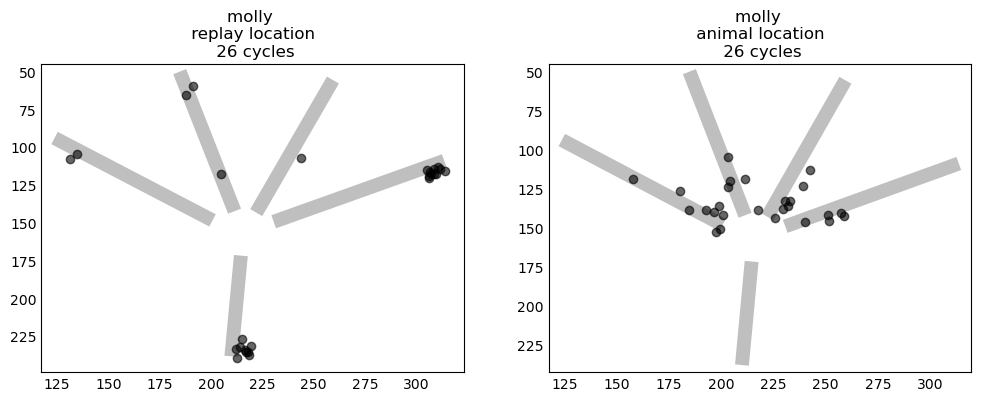

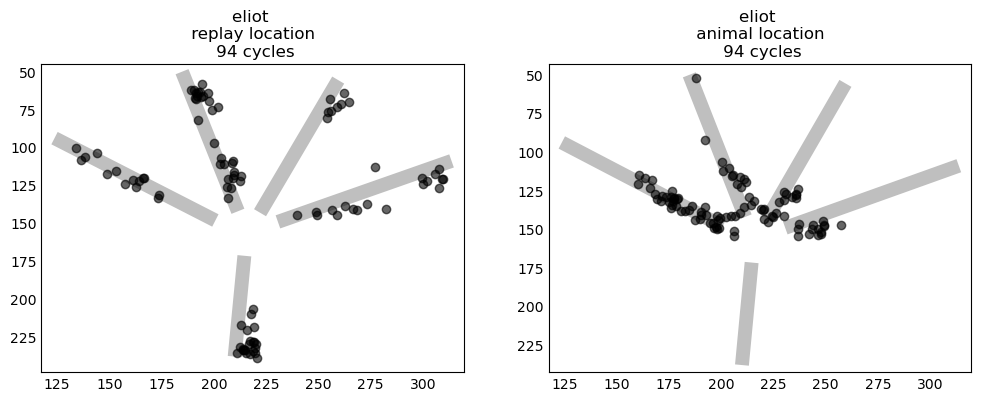

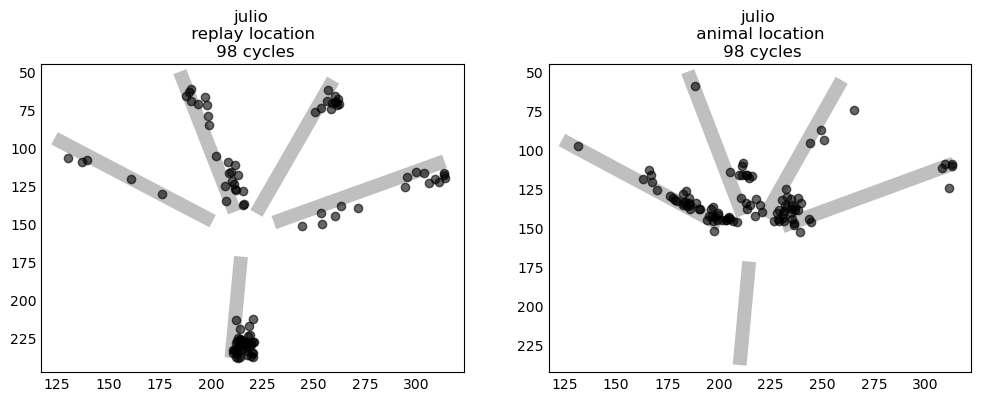

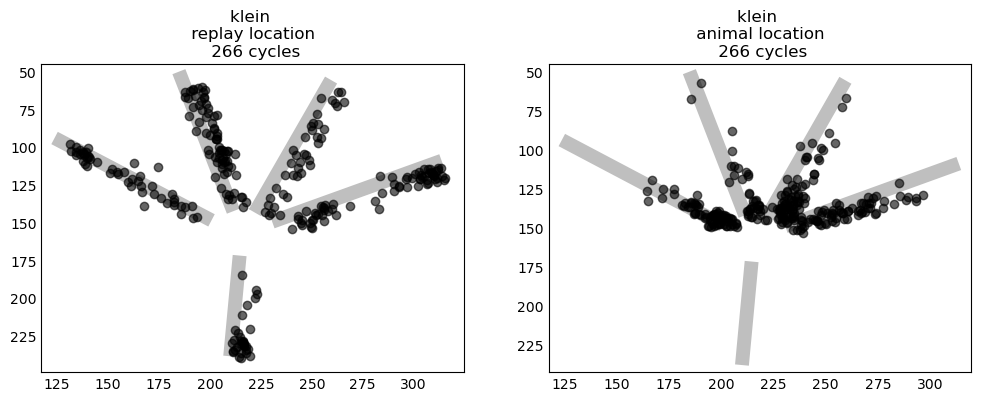

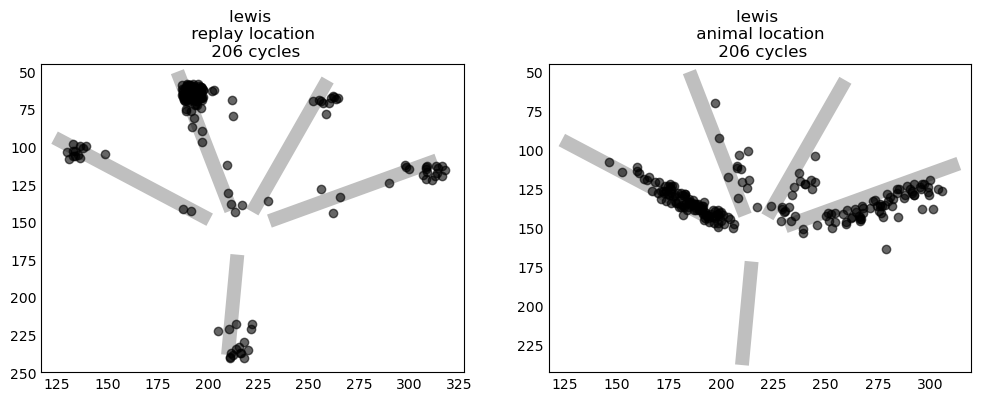

In [415]:
animal_ind = 0
animals = ["molly","eliot","julio","klein","lewis"]

output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4/'
for animal in animals:
    
    list_of_days = list_of_days_animals[animal]
    encoding_set = encoding_set_animals[animal]
    classifier_param_name = classifier_param_name_animals[animal]

    save_name = return_save_name(animal, encoding_set, classifier_param_name, list_of_days[0], list_of_days[-1], proportion = 0.1)
    file_path = output_folder + save_name + '.pkl'
    
    with open(file_path, 'rb') as file:
        loaded_data = pickle.load(file)
        print(f"Successfully loaded data from '{file_path}':")

    replay_locations = loaded_data["replay_locations"]
    animal_locations = loaded_data["animal_locations"]

    plot_density(replay_locations, animal_locations, use_mean = True)

    file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure4/"
    plt.savefig(file_path + f"location_by_event{animal}.pdf",bbox_inches='tight')
    plt.savefig(file_path + f"location_by_event{animal}.png",bbox_inches='tight')


### Quantify for all outer arms

In [318]:
animal_ind = 0
animals = ["molly","eliot","julio","klein","lewis"]

replay_arm_proportions_animals = {}

output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4/'
for animal in animals:
    
    list_of_days = list_of_days_animals[animal]
    encoding_set = encoding_set_animals[animal]
    classifier_param_name = classifier_param_name_animals[animal]

    save_name = return_save_name(animal, encoding_set, classifier_param_name, list_of_days[0], list_of_days[-1], proportion = 0.1)
    file_path = output_folder + save_name + '.pkl'
    
    with open(file_path, 'rb') as file:
        loaded_data = pickle.load(file)
        print(f"Successfully loaded data from '{file_path}':")

    replay_arm_proportions = loaded_data["replay_arm_proportions"]
    replay_arm_identities = np.array(loaded_data["replay_arm_identities"])

    prop_mean_per_cycle = []
    for r in replay_arm_proportions: # get rid of some occasional 1-2 datapoints are off the arm
        r = r[r > 0]
        r = r[r < 1]
        prop_mean_per_cycle.append(np.mean(r))

    prop_mean_per_cycle = np.array(prop_mean_per_cycle)
    assert len(prop_mean_per_cycle) == len(replay_arm_identities)

    replay_arm_proportions_animals[animal] = {}

    for a in [0,1,2,3,4]:
        prop = prop_mean_per_cycle[replay_arm_identities == a]
        if a == 0:
            replay_arm_proportions_animals[animal][a] = 1 - prop
        else:
            replay_arm_proportions_animals[animal][a] = prop

Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/molly_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20220416_20220420_p0.1_remote_locations.pkl':
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/eliot_2Dheadspeed_above_4_andlowmua_default_decoding_gpu_4armMaze_20221018_20221026_p0.1_remote_locations.pkl':
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/julio_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20230731_20230811_p0.1_remote_locations.pkl':
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/klein_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20231101_20231111_p0.1_remote_locations.pkl':
Successfully loaded data from '/stelmo/shijie/change_of_mind_analysis/figure4/lewis_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_20240105_20240114_p0.1_remote_locations.pkl':


### Make bar plot

In [296]:
import seaborn as sns

In [369]:
hist_pct = {}
hist_count = {}

bin_width = 0.2
bins = np.arange(0,1+bin_width,bin_width)


for animal in ["molly","eliot","julio","klein","lewis"]:
    
    hist_count[animal], hist_pct[animal] = {}, {}
    for arm in replay_arm_proportions_animals[animal]:
        data = replay_arm_proportions_animals[animal][arm]
        hist, bin_edges = np.histogram(data, bins, weights = np.ones_like(data)/len(data))
        hist_pct[animal][arm] = hist

        hist, bin_edges = np.histogram(data, bins)
        hist_count[animal][arm] = hist
    


In [371]:
def return_sd_prop(p,n):
    sd = np.sqrt(p*(1-p)/n)
    sd[n == 0] = 0
    return sd

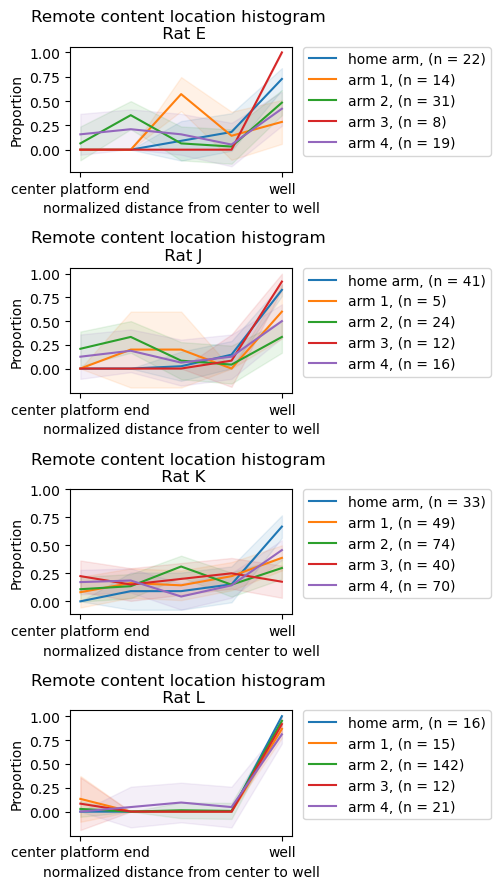

In [393]:
animal_ind = 0

fig, axes = plt.subplots(4,1,figsize = (5.2,9))
animals = ["eliot","julio","klein","lewis"]

output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4/'
for animal in animals:
    
    for arm in [0,1,2,3,4]:
        n = hist_count[animal][arm]
        p = hist_pct[animal][arm]
        sd = return_sd_prop(p,n)

        if arm == 0:
            label = f'home arm, (n = {np.sum(n)})'
        else:
            label = f'arm {arm}, (n = {np.sum(n)})'
        axes[animal_ind].plot(bins[:-1], p, color = 'C'+str(arm),label = label)
        axes[animal_ind].fill_between(bins[:-1], p-sd, p + sd, alpha = 0.1, color = 'C'+str(arm))
        
    axes[animal_ind].set_title('Remote content location histogram \n Rat ' + str(animal[0]).upper())
    axes[animal_ind].set_ylabel("Proportion")
    axes[animal_ind].set_xlabel("normalized distance from center to well")
    axes[animal_ind].set_xticks([0,0.8])
    axes[animal_ind].set_xticklabels(['center platform end','well'])
    axes[animal_ind].set_yticks(np.linspace(0,1,5))
    #axes.set_yticks(np.linspace(0,1,5))

    axes[animal_ind].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

    animal_ind += 1
    
plt.tight_layout()
file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/figure4/"
plt.savefig(file_path + "arm_proportion.pdf",bbox_inches='tight')
plt.savefig(file_path + "arm_proportion.png",bbox_inches='tight')